# Arc Calibration — correcting encoder & OTOS odometry to the camera

Each row is one **constant-(L,R) arc** (so a circular arc) driven on the playfield,
fully inside the table by the `safe_pilot` guard. For **camera, encoder, OTOS, fused**
we recorded **Δyaw** (deg) and **Δpath-distance** (mm), plus the commanded wheel speed.

The camera is ground truth. Goal: speed-aware corrections mapping encoder & OTOS
yaw + distance onto the camera.

Physical trackwidth = **128 mm** (measured, centerline-to-centerline) — fixed.
Firmware heading model: `dθ = (dR − dL) / tw · slip`. We solve for the *effective
slip* the data implies (tw held at 128).

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
for path in ["arc_data.csv", "tests/bench/arc_data.csv",
             "/Volumes/Proj/proj/RobotProjects/radio-robot-c/tests/bench/arc_data.csv"]:
    if os.path.exists(path):
        break
df = pd.read_csv(path)
TW, SLIP0 = 128.0, 0.973   # firmware slip now calibrated to 0.973
df["spd"]     = (df.cmd_L + df.cmd_R) / 2.0      # forward wheel speed (mm/s)
df["absyaw"]  = df.cam_yaw.abs()
df["yawrate"] = df.absyaw / df.dur               # deg/s (turn dynamics)
df["ediff"]   = df.enc_dR - df.enc_dL            # encoder wheel differential (mm)
print(len(df), "rows:", df.kind.value_counts().to_dict())
df.head()

19 rows: {'arcL': 6, 'arcR': 6, 'straight': 3, 'turnL': 2, 'turnR': 2}


,kind,cmd_L,cmd_R,speed,dur,reason,cam_dist,cam_yaw,enc_dL,enc_dR,enc_dist,enc_yaw,otos_dist,otos_yaw,fused_dist,fused_yaw,spd,absyaw,yawrate,ediff
0,straight,90,90,90.0,1.6,done,162.483710,2.858735,158,161,159.5,1.306612,167.373701,2.64,167.373701,2.64,90.0,2.858735,1.786709,3
1,arcL,70,110,90.0,1.6,ABORT_EDGE,111.491908,23.585442,88,136,112.0,20.905798,113.081310,21.79,113.081310,21.79,90.0,23.585442,14.740901,48
2,arcR,110,70,90.0,1.6,done,177.775629,-30.759812,201,132,166.5,-30.052084,166.133409,-30.06,167.297010,-30.04,90.0,30.759812,19.224882,-69
3,arcL,45,135,90.0,1.6,ABORT_EDGE,111.138196,44.387521,66,157,111.5,39.633908,110.607854,41.92,110.607854,41.92,90.0,44.387521,27.742200,91
4,arcR,135,45,90.0,1.6,done,183.052344,-60.291856,239,101,170.0,-60.104168,167.310100,-59.56,168.562155,-59.56,90.0,60.291856,37.682410,-138


## Yaw — encoder

`slip_eff = radians(cam_yaw) · tw / (dR − dL)` is the slip that *would* make the
encoder heading equal the camera, with tw fixed at the true 128 mm.

In [2]:
turns = df[df.absyaw > 5].copy()
turns["slip_eff"]  = np.radians(turns.cam_yaw) * TW / turns.ediff
turns["enc_ratio"] = turns.cam_yaw / turns.enc_yaw
print("ENCODER YAW")
print("  cam/enc ratio   mean %.3f ± %.3f   (under-report %.1f%%)"
      % (turns.enc_ratio.mean(), turns.enc_ratio.std(), (turns.enc_ratio.mean()-1)*100))
print("  effective slip  mean %.3f ± %.3f   (firmware now %.2f)"
      % (turns.slip_eff.mean(), turns.slip_eff.std(), SLIP0))

ENCODER YAW
  cam/enc ratio   mean 1.023 ± 0.062   (under-report 2.3%)
  effective slip  mean 0.996 ± 0.060   (firmware now 0.97)


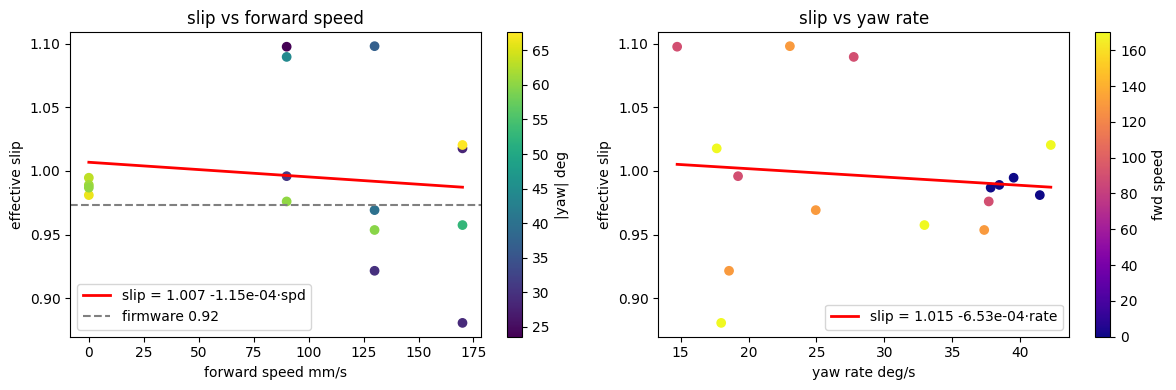

slope vs speed -1.15e-04 /(mm/s);  vs yawrate -6.53e-04 /(deg/s)


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sc = ax[0].scatter(turns.spd, turns.slip_eff, c=turns.absyaw, cmap="viridis")
plt.colorbar(sc, ax=ax[0], label="|yaw| deg")
m, b = np.polyfit(turns.spd, turns.slip_eff, 1)
xs = np.linspace(turns.spd.min(), turns.spd.max(), 50)
ax[0].plot(xs, m*xs + b, "r-", lw=2, label="slip = %.3f %+.2e·spd" % (b, m))
ax[0].axhline(SLIP0, ls="--", c="gray", label="firmware 0.92")
ax[0].set(xlabel="forward speed mm/s", ylabel="effective slip", title="slip vs forward speed")
ax[0].legend()
sc2 = ax[1].scatter(turns.yawrate, turns.slip_eff, c=turns.spd, cmap="plasma")
plt.colorbar(sc2, ax=ax[1], label="fwd speed")
m2, b2 = np.polyfit(turns.yawrate, turns.slip_eff, 1)
xs2 = np.linspace(turns.yawrate.min(), turns.yawrate.max(), 50)
ax[1].plot(xs2, m2*xs2 + b2, "r-", lw=2, label="slip = %.3f %+.2e·rate" % (b2, m2))
ax[1].set(xlabel="yaw rate deg/s", ylabel="effective slip", title="slip vs yaw rate")
ax[1].legend()
plt.tight_layout(); plt.savefig("/tmp/slip_fit.png", dpi=80); plt.show()
print("slope vs speed %.2e /(mm/s);  vs yawrate %.2e /(deg/s)" % (m, m2))

## Yaw — OTOS and fused

In [4]:
turns["otos_ratio"]  = turns.cam_yaw / turns.otos_yaw
turns["fused_ratio"] = turns.cam_yaw / turns.fused_yaw
print("OTOS  yaw cam/otos   mean %.3f ± %.3f" % (turns.otos_ratio.mean(),  turns.otos_ratio.std()))
print("FUSED yaw cam/fused  mean %.3f ± %.3f" % (turns.fused_ratio.mean(), turns.fused_ratio.std()))

OTOS  yaw cam/otos   mean 1.015 ± 0.035
FUSED yaw cam/fused  mean 1.015 ± 0.035


## Distance (path length)

ENCODER dist cam/enc   mean 1.032 ± 0.031
OTOS    dist cam/otos  mean 1.032 ± 0.036


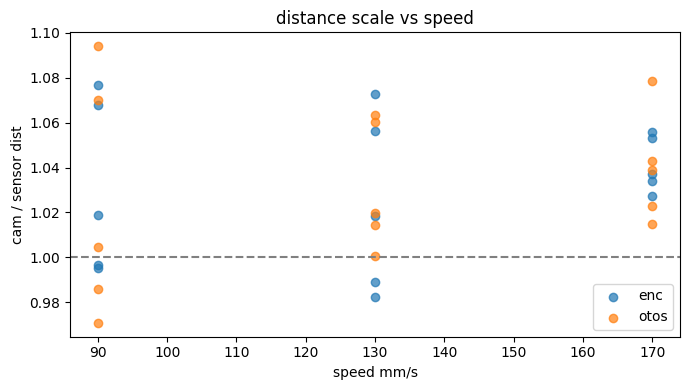

In [5]:
d = df[df.cam_dist > 40].copy()
d["enc_ds"]  = d.cam_dist / d.enc_dist
d["otos_ds"] = d.cam_dist / d.otos_dist
print("ENCODER dist cam/enc   mean %.3f ± %.3f" % (d.enc_ds.mean(),  d.enc_ds.std()))
print("OTOS    dist cam/otos  mean %.3f ± %.3f" % (d.otos_ds.mean(), d.otos_ds.std()))
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(d.spd, d.enc_ds,  label="enc",  alpha=.7)
ax.scatter(d.spd, d.otos_ds, label="otos", alpha=.7)
ax.axhline(1, ls="--", c="gray")
ax.set(xlabel="speed mm/s", ylabel="cam / sensor dist", title="distance scale vs speed"); ax.legend()
plt.tight_layout(); plt.savefig("/tmp/dist_fit.png", dpi=80); plt.show()

## Recommended corrections

In [6]:
slip_rec = turns.slip_eff.mean()
print("="*58)
print("RECOMMENDED CORRECTIONS  (map sensor -> camera)")
print("="*58)
print()
print("ENCODER YAW   cam/enc = %.3f (%+.1f%%) at firmware slip %.3f; effective slip = %.3f"
      % (turns.enc_ratio.mean(), (turns.enc_ratio.mean()-1)*100, SLIP0, slip_rec))
print("  speed trend: slip %.3f @ %.0f mm/s .. %.3f @ %.0f mm/s"
      % (b + m*turns.spd.min(), turns.spd.min(), b + m*turns.spd.max(), turns.spd.max()))
print()
print("ENCODER DIST  cam/enc = %.3f  ->  scale mm_per_wheel_deg by %.3f" % (d.enc_ds.mean(), d.enc_ds.mean()))
print()
oy, od = turns.otos_ratio.mean(), d.otos_ds.mean()
print("OTOS YAW      cam/otos = %.3f  ->  %s" % (oy, "OK as-is" if abs(oy-1) < .03 else "scale by %.3f" % oy))
print("OTOS DIST     cam/otos = %.3f  ->  %s" % (od, "OK as-is" if abs(od-1) < .03 else "scale by %.3f" % od))

RECOMMENDED CORRECTIONS  (map sensor -> camera)

ENCODER YAW   cam/enc = 1.023 (+2.3%) at firmware slip 0.973; effective slip = 0.996
  speed trend: slip 1.007 @ 0 mm/s .. 0.987 @ 170 mm/s

ENCODER DIST  cam/enc = 1.032  ->  scale mm_per_wheel_deg by 1.032

OTOS YAW      cam/otos = 1.015  ->  OK as-is
OTOS DIST     cam/otos = 1.032  ->  scale by 1.032
